# Importando a base de dados

Esta base de dados é utilizada mostrando a venda de jogos, pedi ajuda para o chatgpt para que ele forneça questões para serem analisadas ao decorrer desta analise, aqui está o prompt que foi utilizado:

quero que você leia a base de dados a seguir, e faça perguntas sem a resolução das questões de nível basico para estudar analise de dados utilizando python, tenho conhecimento nas bibliotecas de analise, pandas, seaborn, matplot e numpy

está é a base: https://raw.githubusercontent.com/carlosvinicius-ai/DataScience/refs/heads/master/BasesDeDados/games/Video_Games_Sales_as_at_22_Dec_2016.csv

In [13]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

games = pd.read_csv('https://raw.githubusercontent.com/carlosvinicius-ai/DataScience/refs/heads/master/BasesDeDados/games/Video_Games_Sales_as_at_22_Dec_2016.csv')
games.head()

,Name,Platform,Year_of_Release,Genre,Publisher,NA_Sales,EU_Sales,JP_Sales,Other_Sales,Global_Sales,Critic_Score,Critic_Count,User_Score,User_Count,Developer,Rating
0,Wii Sports,Wii,2006.0,Sports,Nintendo,41.36,28.96,3.77,8.45,82.53,76.0,51.0,8,322.0,Nintendo,E
1,Super Mario Bros.,NES,1985.0,Platform,Nintendo,29.08,3.58,6.81,0.77,40.24,NaN,NaN,NaN,NaN,NaN,NaN
2,Mario Kart Wii,Wii,2008.0,Racing,Nintendo,15.68,12.76,3.79,3.29,35.52,82.0,73.0,8.3,709.0,Nintendo,E
3,Wii Sports Resort,Wii,2009.0,Sports,Nintendo,15.61,10.93,3.28,2.95,32.77,80.0,73.0,8,192.0,Nintendo,E
4,Pokemon Red/Pokemon Blue,GB,1996.0,Role-Playing,Nintendo,11.27,8.89,10.22,1.00,31.37,NaN,NaN,NaN,NaN,NaN,NaN


## Exploração Inicial
1. Quais são as colunas presentes na base de dados?
2. Quantos registros (linhas) existem na base de dados?
3. Existem valores ausentes na base? Em quais colunas?
4. Quais são os tipos de dados de cada coluna?

In [3]:
print(f'Os nomes das colunas presentes são: {games.columns}')

Os nomes das colunas presentes são: Index(['Name', 'Platform', 'Year_of_Release', 'Genre', 'Publisher', 'NA_Sales',
       'EU_Sales', 'JP_Sales', 'Other_Sales', 'Global_Sales', 'Critic_Score',
       'Critic_Count', 'User_Score', 'User_Count', 'Developer', 'Rating'],
      dtype='object')


In [4]:
print(f'Existem: {games.shape[0]} linhas na base')

Existem: 16719 linhas na base


In [5]:
print(games.isnull().sum())

Name                  2
Platform              0
Year_of_Release     269
Genre                 2
Publisher            54
NA_Sales              0
EU_Sales              0
JP_Sales              0
Other_Sales           0
Global_Sales          0
Critic_Score       8582
Critic_Count       8582
User_Score         6704
User_Count         9129
Developer          6623
Rating             6769
dtype: int64


In [6]:
games.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 16719 entries, 0 to 16718
Data columns (total 16 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Name             16717 non-null  object 
 1   Platform         16719 non-null  object 
 2   Year_of_Release  16450 non-null  float64
 3   Genre            16717 non-null  object 
 4   Publisher        16665 non-null  object 
 5   NA_Sales         16719 non-null  float64
 6   EU_Sales         16719 non-null  float64
 7   JP_Sales         16719 non-null  float64
 8   Other_Sales      16719 non-null  float64
 9   Global_Sales     16719 non-null  float64
 10  Critic_Score     8137 non-null   float64
 11  Critic_Count     8137 non-null   float64
 12  User_Score       10015 non-null  object 
 13  User_Count       7590 non-null   float64
 14  Developer        10096 non-null  object 
 15  Rating           9950 non-null   object 
dtypes: float64(9), object(7)
memory usage: 2.0+ MB


## Análises Categóricas
5. Quais são as plataformas de videogame presentes na base?

6. Qual plataforma possui o maior número de jogos lançados?

7. Qual é o gênero de jogo mais frequente?

8. Quais são as 5 editoras (publishers) com o maior número de jogos lançados?

9. Qual é a distribuição de jogos por plataforma?

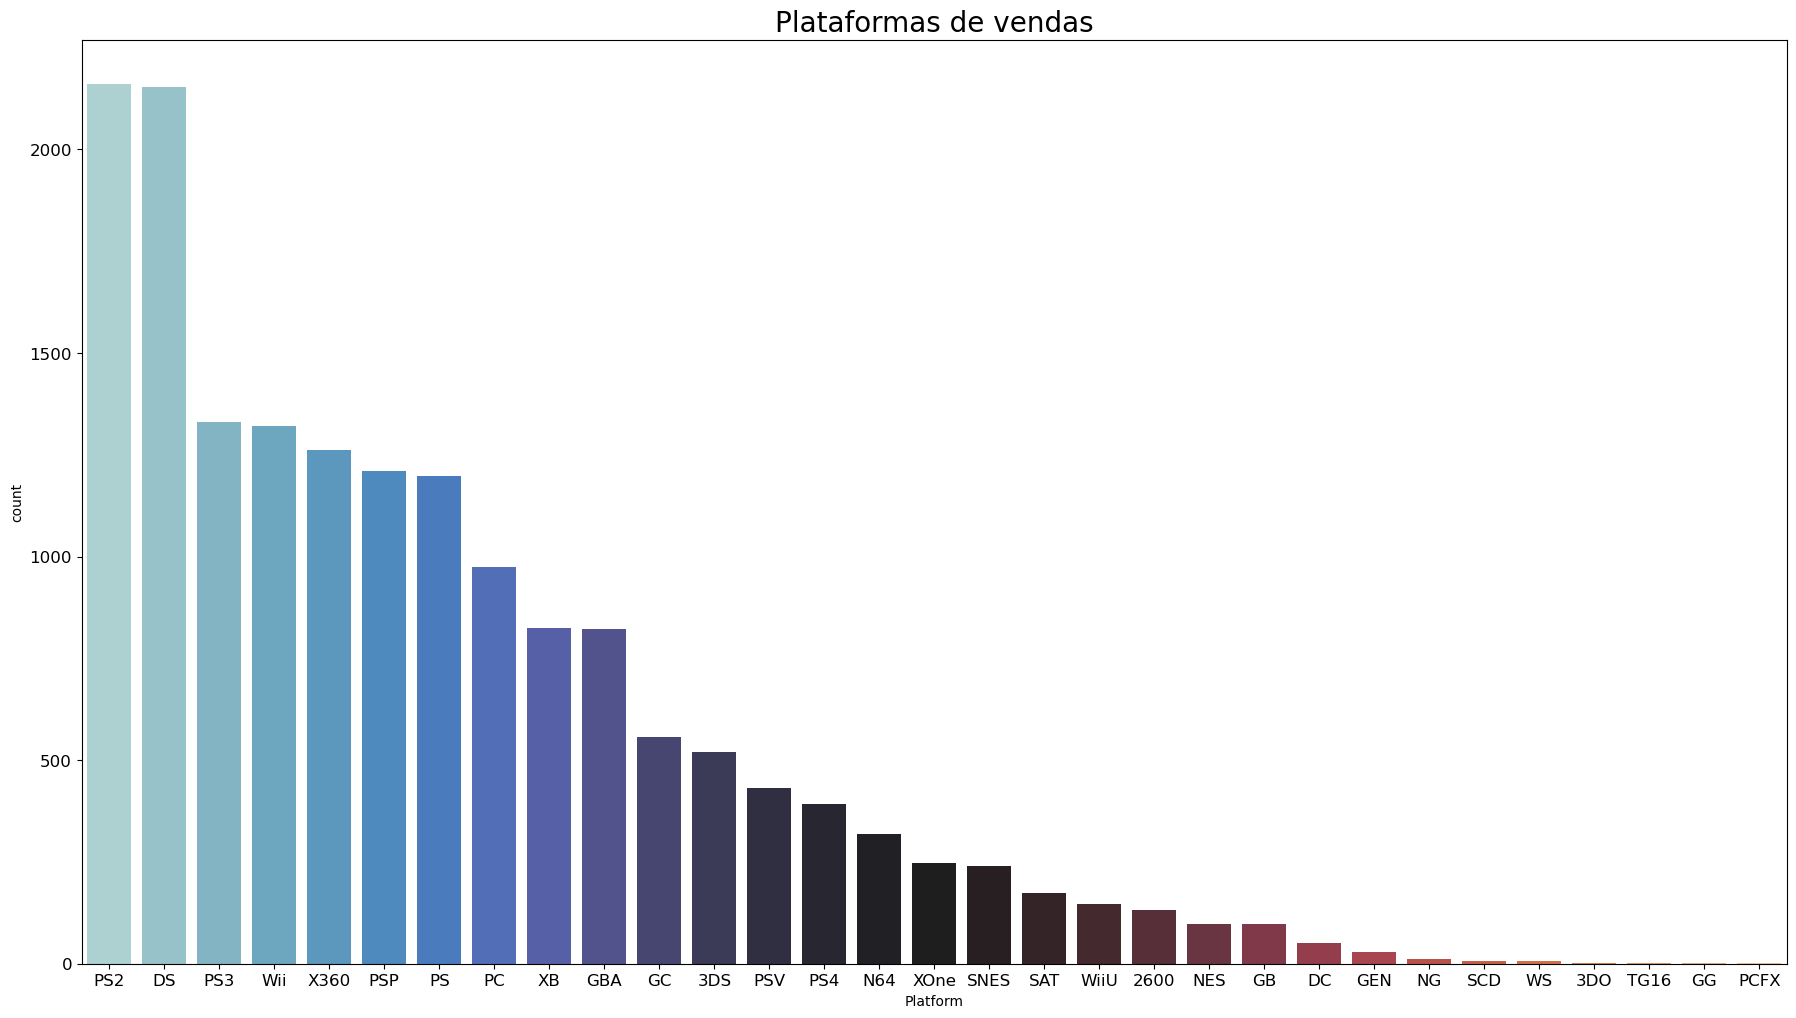

In [7]:
ordem_plataforma = games['Platform'].value_counts().index
plt.figure(figsize=(22, 12))
sns.countplot(x='Platform', data=games, order=ordem_plataforma, hue='Platform', palette='icefire', hue_order=ordem_plataforma)
plt.title('Plataformas de vendas', fontsize=20)
plt.xticks(fontsize=12)
plt.yticks(fontsize=12)
plt.show()

In [8]:
maior_numero_de_jogos = games['Platform'].value_counts().to_frame().reset_index()
maior_numero_de_jogos.columns = ['Plataforma', 'Quantidade']
maior_numero_de_jogos.head(1)

,Plataforma,Quantidade
0,PS2,2161


In [9]:
genero_frequente = games['Genre'].value_counts().to_frame().reset_index()
genero_frequente.columns = ['Genero', 'Frequencia']
genero_frequente.head(1)

,Genero,Frequencia
0,Action,3370


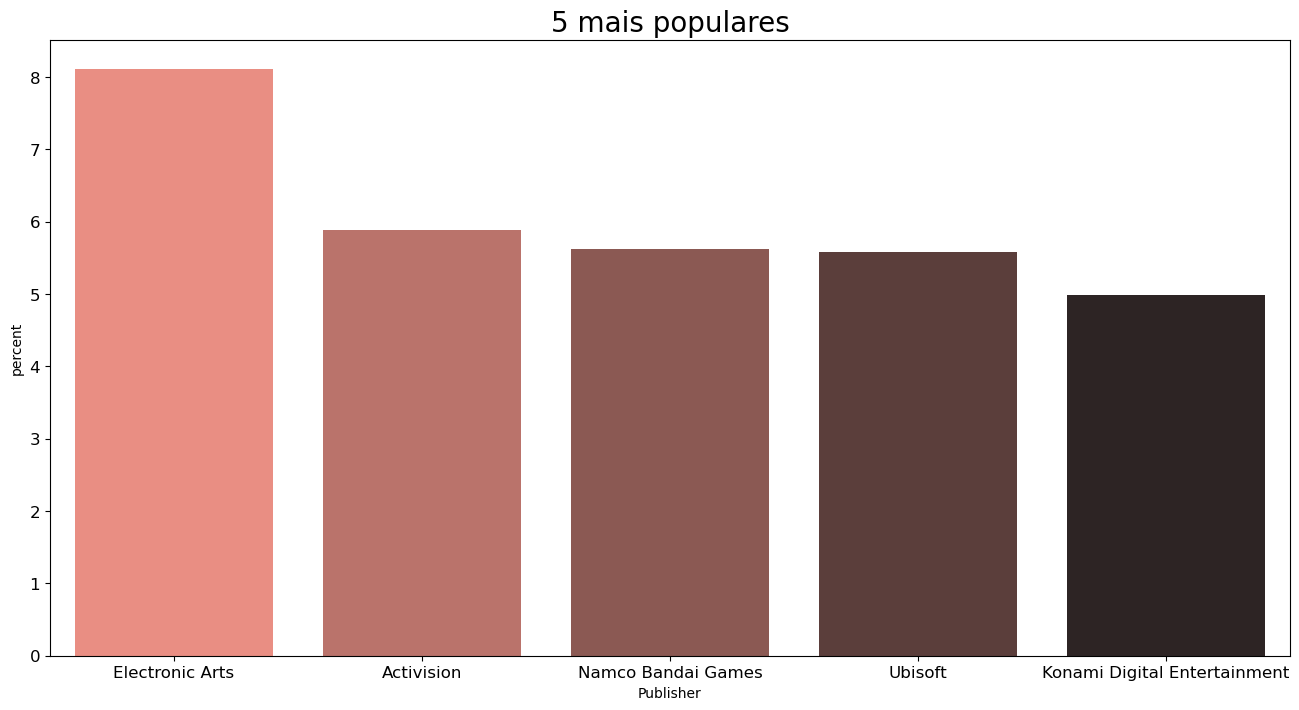

In [10]:
editora_popular = games['Publisher'].value_counts().head(5).index # trazendo as mais populares e seu index
plt.figure(figsize=(16,8))
sns.countplot(x='Publisher', data=games,order=editora_popular, hue='Publisher', palette='dark:salmon_r', hue_order=editora_popular, legend=False, stat='percent')
plt.title('5 mais populares', fontsize=20)
plt.xticks(fontsize=12)
plt.yticks(fontsize=12)
plt.show()